## Get final harmonized counts for Matched NanoString & RNA-seq samples
Considering the following:
1. Exon-based counts vs Isoform based counts
2. Normalized RNA-seq counts based on TPM, RPKM, and MR (DESeq2)
3. Bayes-based shrunked Log2FC vs raw Log2FC

In [2]:
library(data.table)
library(stringr)
library(DESeq2)

## 1. Harmonize column names
Change column names in counts that are based on file names to nicer names based on metadata

In [3]:
meta <- fread("../../data/meta//Nano_Metadata.csv", sep=",")
meta[1:2,]
table(meta$Study_Patient_ID)
table(meta$Study_Sample_ID)
meta$name <- paste0(meta$Study_Sample_ID, "_", meta$Study_Patient_ID)

Specimen_Type,Study_Patient_ID,Study_Sample_ID,Assay(s),Sample_Type,Diagnosis,Anatomical_Site,Date_of_Collection,Sex
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
Tumor,S10-018931A6,BB24_01,xR Whole Transcriptome,Tumor,High grade serous carcinoma of the ovary,Right fallopian tube and ovary,12/1/2010,F
Tumor,S14-002474B2,BB24_02,xR Whole Transcriptome,Tumor,High grade serous carcinoma of the ovary,Left fallopian tube and ovary,2/1/2014,F



 S10-016752C1  S10-016783A2  S10-017623A2  S10-018931A6  S11-003355A1 
            1             1             1             1             1 
   S11-011709  S11-012085C1  S12-003590C5  S12-008138A2    S12-011538 
            1             1             1             1             1 
 S13-002699A4  S13-003620D2  S13-008160A2  S13-009885J1  S13-019142C2 
            1             1             1             1             1 
 S13-021353A4  S14-002474B2  S14-012409D2  S16-007066C1  S16-023867D1 
            1             1             1             1             1 
 S17-018143A2  S21-024801A2 S21-028943A10  S21-032280A2    S22-003884 
            1             1             1             1             1 
 S22-009274B7  S22-010607B2 
            1             1 


BB24_01 BB24_02 BB24_03 BB24_04 BB24_05 BB24_06 BB24_07 BB24_08 BB24_09 BB24_10 
      1       1       1       1       1       1       1       1       1       1 
BB24_11 BB24_12 BB24_13 BB24_14 BB24_15 BB24_16 BB24_17 BB24_18 BB24_19 BB24_20 
      1       1       1       1       1       1       1       1       1       1 
BB24_21 BB24_22 BB24_23 BB24_24 BB24_25 BB24_26 BB24_27 
      1       1       1       1       1       1       1 

In [4]:
# Read in the counts and remove the fluff from the names
rnaseq <- fread("../../data/Matched/RNAMatch4.18_str_gtf_transcripts.txt")
colnames(rnaseq) <- gsub(".*/|_T_.*", "", colnames(rnaseq))
rnaseq[1:2,]
rnaseq_gene <- fread("../../data/Matched/RNAMatch4.18_str_gtf_genes.txt")
colnames(rnaseq_gene) <- gsub(".*/|_T_.*", "", colnames(rnaseq_gene))
rnaseq_gene[1:2,]
rnaseq_exon <- fread("../../data/Matched/RNAMatch4.18_str_gtf_matchedexons.txt")
colnames(rnaseq_exon) <- gsub(".*/|_T_.*", "", colnames(rnaseq_exon))
rnaseq_exon[1:2,]
nano <- fread("../../data/Matched//Norm_counts_3.24.25.txt")
nano[1:2,]
colnames(nano) <- gsub("20250320_30103031210726-01_|20250318_30103031230726-01_|.RCC|_\\d+\\.RCC", "", colnames(nano))
nano[1:2,]

Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538,BB24_27_S22-003884
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,51,60,37,40,42,100,28,88,46,34


Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538,BB24_27_S22-003884
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,51,60,37,40,42,100,28,88,46,34


Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538,BB24_27_S22-003884
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A2M:NM_000014.4,chr12,9099380,9099523,-,144,1675,1014,1210,1919,...,658,662,2519,1111,2087,1970,2012,681,4620,3224
ADORA2A:NM_000675.5,chr22,24440582,24442357,+,1776,70,36,32,68,...,61,30,66,32,32,50,51,39,106,74


Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,20250320_30103031210726-01_S13-9885 J1_01.RCC,20250320_30103031210726-01_S14-12409 D2_05.RCC,20250320_30103031210726-01_S14-2474 B2_04.RCC,20250320_30103031210726-01_S16-23867 D1_06.RCC,20250320_30103031210726-01_S16-7066 C1_07.RCC,20250320_30103031210726-01_S17-18143 A2_08.RCC,20250320_30103031210726-01_S21-24801 A2_11.RCC,20250320_30103031210726-01_S21-28943 A10_10.RCC,20250320_30103031210726-01_S21-32280 A2_09.RCC,20250320_30103031210726-01_S22-9274 B7_12.RCC
<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,S13-9885 J1,S14-12409 D2,S14-2474 B2,S16-23867 D1,S16-7066 C1,S17-18143 A2,S21-24801 A2,S21-28943 A10,S21-32280 A2,S22-9274 B7
<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


In [5]:
sort(meta$Study_Patient_ID)
sort(colnames(rnaseq))
sort(colnames(nano))

setdiff(colnames(rnaseq), meta$name)

[1] "S10-016752C1"  "S10-016783A2"  "S10-017623A2"  "S10-018931A6" 
 [5] "S11-003355A1"  "S11-011709"    "S11-012085C1"  "S12-003590C5" 
 [9] "S12-008138A2"  "S12-011538"    "S13-002699A4"  "S13-003620D2" 
[13] "S13-008160A2"  "S13-009885J1"  "S13-019142C2"  "S13-021353A4" 
[17] "S14-002474B2"  "S14-012409D2"  "S16-007066C1"  "S16-023867D1" 
[21] "S17-018143A2"  "S21-024801A2"  "S21-028943A10" "S21-032280A2" 
[25] "S22-003884"    "S22-009274B7"  "S22-010607B2"

[1] "BB24_01_S10-018931A6"  "BB24_02_S14-002474B2"  "BB24_03_S21-024801A2" 
 [4] "BB24_04_S10-016783A2"  "BB24_05_S22-010607B2"  "BB24_06_S10-016752C1" 
 [7] "BB24_07_S10-017623A2"  "BB24_08_S11-003355A1"  "BB24_09_S11-012085C1" 
[10] "BB24_10_S12-003590C5"  "BB24_11_S12-008138A2"  "BB24_12_S13-003620D2" 
[13] "BB24_14_S13-008160A2"  "BB24_15_S16-023867D1"  "BB24_16_S16-007066C1" 
[16] "BB24_17_S21-032280A2"  "BB24_18_S13-009885J1"  "BB24_19_S17-018143A2" 
[19] "BB24_20_S13-019142C2"  "BB24_21_S13-021353A4"  "BB24_22_S14-012409D2" 
[22] "BB24_23_S22-009274B7"  "BB24_24_S21-028943A10" "BB24_25_S11-011709"   
[25] "BB24_26_S12-011538"    "BB24_27_S22-003884"    "Chr"                  
[28] "End"                   "Geneid"                "Length"               
[31] "Start"                 "Strand"

[1] "% Samples above Threshold" "Accession #"              
 [3] "Analyte Type"              "Annotation"               
 [5] "Avg Count"                 "Class Name"               
 [7] "Max Count"                 "Min Count"                
 [9] "NS Probe ID"               "Positive Flag"            
[11] "Probe Name"                "S10-16752 C1"             
[13] "S10-16783 A2"              "S10-17623 A2"             
[15] "S10-18931 A6"              "S11-11709 A2"             
[17] "S11-12085 C1"              "S11-3355 A1 "             
[19] "S12-11538 B3"              "S12-3590 C5"              
[21] "S12-8138 A2"               "S13-19142 C2"             
[23] "S13-21353 A4"              "S13-3620 D2"              
[25] "S13-8160 A2"               "S13-9885 J1"              
[27] "S14-12409 D2"              "S14-2474 B2"              
[29] "S16-23867 D1"              "S16-7066 C1"              
[31] "S17-18143 A2"              "S21-24801 A2"             
[33] "S21-28943 A10"             "S21-32280 A2"             
[35] "S22-9274 B7"               "Target Sequence"

[1] "Geneid" "Chr"    "Start"  "End"    "Strand" "Length"

In [6]:
# Figure out which nano names match the RNA seq names
new_nano_colnames = c()
for (colname in colnames(nano)) {
    if (startsWith(colname, "S")) {
        # if a sample get the id to match RNAseq
    split <- str_split_fixed(colname, "-", 2)
    split2 <- str_split_fixed(split[,2], " ", 2)
    grep_name = paste0(split2[,1], split2[,2])
        
    grep_result = meta$name[grep(grep_name, meta$name)]
        if (length(grep_result) > 0) {
            # if can find using letter and number
            cat("\n", colname, "\t", grep_result)
            new_nano_colnames = c(new_nano_colnames, grep_result)
            } else {
            # otherwise just use number (somtimes letter not included for some reason?)
        grep_result = meta$name[grep(split2[,1], meta$name)]    
            cat("\n", colname, "\t", grep_result)
            new_nano_colnames = c(new_nano_colnames, grep_result)
            }
    
        } else {
        # if not a count name just keep colname
    new_nano_colnames = c(new_nano_colnames, colname)
    }
    }
# check no duplicates
new_nano_colnames[duplicated(new_nano_colnames)]


 S10-16752 C1 	 BB24_06_S10-016752C1
 S10-16783 A2 	 BB24_04_S10-016783A2
 S10-17623 A2 	 BB24_07_S10-017623A2
 S10-18931 A6 	 BB24_01_S10-018931A6
 S11-11709 A2 	 BB24_25_S11-011709
 S11-12085 C1 	 BB24_09_S11-012085C1
 S11-3355 A1  	 BB24_08_S11-003355A1
 S12-11538 B3 	 BB24_26_S12-011538
 S12-3590 C5 	 BB24_10_S12-003590C5
 S12-8138 A2 	 BB24_11_S12-008138A2
 S13-3620 D2 	 BB24_12_S13-003620D2
 S13-8160 A2 	 BB24_14_S13-008160A2
 S13-19142 C2 	 BB24_20_S13-019142C2
 S13-21353 A4 	 BB24_21_S13-021353A4
 S13-9885 J1 	 BB24_18_S13-009885J1
 S14-12409 D2 	 BB24_22_S14-012409D2
 S14-2474 B2 	 BB24_02_S14-002474B2
 S16-23867 D1 	 BB24_15_S16-023867D1
 S16-7066 C1 	 BB24_16_S16-007066C1
 S17-18143 A2 	 BB24_19_S17-018143A2
 S21-24801 A2 	 BB24_03_S21-024801A2
 S21-28943 A10 	 BB24_24_S21-028943A10
 S21-32280 A2 	 BB24_17_S21-032280A2
 S22-9274 B7 	 BB24_23_S22-009274B7

character(0)

In [7]:
new_nano_colnames
colnames(nano) <- new_nano_colnames
dim(nano)
dim(rnaseq)
dim(rnaseq_gene)
dim(rnaseq_exon)

[1] "Probe Name"                "Annotation"               
 [3] "Accession #"               "NS Probe ID"              
 [5] "Class Name"                "Analyte Type"             
 [7] "Target Sequence"           "% Samples above Threshold"
 [9] "Positive Flag"             "Avg Count"                
[11] "Min Count"                 "Max Count"                
[13] "BB24_06_S10-016752C1"      "BB24_04_S10-016783A2"     
[15] "BB24_07_S10-017623A2"      "BB24_01_S10-018931A6"     
[17] "BB24_25_S11-011709"        "BB24_09_S11-012085C1"     
[19] "BB24_08_S11-003355A1"      "BB24_26_S12-011538"       
[21] "BB24_10_S12-003590C5"      "BB24_11_S12-008138A2"     
[23] "BB24_12_S13-003620D2"      "BB24_14_S13-008160A2"     
[25] "BB24_20_S13-019142C2"      "BB24_21_S13-021353A4"     
[27] "BB24_18_S13-009885J1"      "BB24_22_S14-012409D2"     
[29] "BB24_02_S14-002474B2"      "BB24_15_S16-023867D1"     
[31] "BB24_16_S16-007066C1"      "BB24_19_S17-018143A2"     
[33] "BB24_03_S21-024801A2"      "BB24_24_S21-028943A10"    
[35] "BB24_17_S21-032280A2"      "BB24_23_S22-009274B7"

[1] 784  36

[1] 200121     32

[1] 49771    32

[1] 765  32

In [8]:
# Only keep samples that are paired (a NanoString and RNAseq sample)
cat("\nColumns in Nano but not RNAseq:", setdiff(new_nano_colnames, colnames(rnaseq)))
cat("\nColumns in RNAseq but not Nano:", setdiff(colnames(rnaseq), new_nano_colnames))
unpaired_cols <- union(setdiff(new_nano_colnames, colnames(rnaseq)), setdiff(colnames(rnaseq), new_nano_colnames))
unpaired_cols <- unpaired_cols[grepl("BB", unpaired_cols)]
length(unpaired_cols)
unpaired_cols

cat("\n", ncol(nano), " ", ncol(rnaseq), " ", ncol(rnaseq_gene), " ", ncol(rnaseq_exon))
rnaseq <- rnaseq[,.SD, .SDcols = !unpaired_cols]
rnaseq_gene <- rnaseq_gene[,.SD, .SDcols = !unpaired_cols]
rnaseq_exon <- rnaseq_exon[,.SD, .SDcols = !unpaired_cols]

cat("\n", ncol(nano), " ", ncol(rnaseq), " ", ncol(rnaseq_gene), " ", ncol(rnaseq_exon))
nano[1:2,]
rnaseq[1:2,]
rnaseq_gene[1:2,]
rnaseq_exon[1:2,]



Columns in Nano but not RNAseq: Probe Name Annotation Accession # NS Probe ID Class Name Analyte Type Target Sequence % Samples above Threshold Positive Flag Avg Count Min Count Max Count
Columns in RNAseq but not Nano: Geneid Chr Start End Strand Length BB24_05_S22-010607B2 BB24_27_S22-003884

[1] 2

[1] "BB24_05_S22-010607B2" "BB24_27_S22-003884"


 36   32   32   32
 36   30   30   30

Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,17,51,60,37,40,42,100,28,88,46


Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
DDX11L1,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
WASH7P,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,17,51,60,37,40,42,100,28,88,46


Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
A2M:NM_000014.4,chr12,9099380,9099523,-,144,1675,1014,1210,1919,...,2512,658,662,2519,1111,2087,1970,2012,681,4620
ADORA2A:NM_000675.5,chr22,24440582,24442357,+,1776,70,36,32,68,...,44,61,30,66,32,32,50,51,39,106


## 2. Get RPKM and TPM normalized counts for RNA-seq
In RPKM, we normalize the gene counts by a scaling factor (based on total number of counts for that sample) and then by length. 

In TPM, we normalize the gene counts by length first and then a scaling factor. Therefore, the sum of TPMs in each sample are the same -- easier to compare proportion of reads with samples. E.g. TPM for gene A in Sample 1 is 3.33 and 2 is 3.33 means the exact same proportion of total reads mapped to genes in each sample. 

In this case, we will always only use the GENE based counts to get the scaling factors. Scaling factors should be accounting for one sample having more general transcription than another sample so we want to consider all genes/exons in this analysis (unlike exon counts) and not double count (transcript based will be counting over the same exon multiple times).


Filter based on TPM being > 1 for WGCNA genes to consider.

In [9]:
calculate_rpkm <- function(gene_dt, trans_dt, exon_dt, length_col = "Length", gene_col = "Geneid") {
    " Caclulates the size factors based on the GENES rather than transcripts to ensure no overlapping counts"
    trans_dt <- as.data.table(trans_dt)
    gene_dt <- as.data.table(gene_dt)

  # Identify sample (count) columns
  sample_cols <- setdiff(names(gene_dt), c(gene_col, length_col, "Chr", "Start", "End", "Strand"))

  # Initialize result data.table with gene ID of transcripts and genes
  rpkm_gene_dt <- gene_dt[, .(Geneid = get(gene_col))]
  rpkm_trans_dt <- trans_dt[, .(Geneid = get(gene_col))]
  rpkm_exon_dt <- exon_dt[, .(Geneid = get(gene_col))]

  # Calculate RPKM per sample and store columns
  for (sample in sample_cols) {
      # calculate size factor based on genes only
    scale_factor <- sum(gene_dt[[sample]]) 
    rpm_gene <- gene_dt[[sample]] / scale_factor * 1e6
    rpm_trans <- trans_dt[[sample]] / scale_factor * 1e6
    rpm_exon <- exon_dt[[sample]] / scale_factor * 1e6
      # now consider the length
    rpkm_gene <-  rpm_gene / (gene_dt[[length_col]] / 1000)
    rpkm_gene_dt[, (paste0(sample, "_RPKM")) := rpkm_gene]
    rpkm_trans <-  rpm_trans / (trans_dt[[length_col]] / 1000)
    rpkm_trans_dt[, (paste0(sample, "_RPKM")) := rpkm_trans]
    rpkm_exon <-  rpm_exon / (exon_dt[[length_col]] / 1000)
    rpkm_exon_dt[, (paste0(sample, "_RPKM")) := rpkm_exon]
  }

  # Calculate median RPKM across samples (vectorized)
  rpkm_cols <- grep("_RPKM$", names(rpkm_gene_dt), value = TRUE)
  rpkm_gene_dt[, Median_RPKM := apply(.SD, 1, median), .SDcols = rpkm_cols]
  rpkm_cols <- grep("_RPKM$", names(rpkm_trans_dt), value = TRUE)
  rpkm_trans_dt[, Median_RPKM := apply(.SD, 1, median), .SDcols = rpkm_cols]
  rpkm_cols <- grep("_RPKM$", names(rpkm_exon_dt), value = TRUE)
  rpkm_exon_dt[, Median_RPKM := apply(.SD, 1, median), .SDcols = rpkm_cols]

  return(list("G"=rpkm_gene_dt, "T"=rpkm_trans_dt, "E"=rpkm_exon_dt))
}

calculate_tpm <- function(gene_dt, trans_dt, exon_dt, length_col = "Length", gene_col = "Geneid") {
  trans_dt <- as.data.table(trans_dt)
  gene_dt <- as.data.table(gene_dt)
  exon_dt <- as.data.table(exon_dt)

  # Identify sample (count) columns
  sample_cols <- setdiff(names(gene_dt), c(gene_col, length_col, "Chr", "Start", "End", "Strand"))

  # Initialize result data.table with gene ID
  tpm_gene_dt <- gene_dt[, .(Geneid = get(gene_col))]
  tpm_trans_dt <- trans_dt[, .(Geneid = get(gene_col))]
  tpm_exon_dt <- exon_dt[, .(Geneid = get(gene_col))]

  # Calculate TPM per sample and store columns
  for (sample in sample_cols) {
    # calculate the scale factor based on the genes rather than transcripts
    rpk_gene <- gene_dt[[sample]] / (gene_dt[[length_col]] / 1000)
    rpk_trans <- trans_dt[[sample]] / (trans_dt[[length_col]] / 1000)
    rpk_exon <- exon_dt[[sample]] / (exon_dt[[length_col]] / 1000)
    scale_factor <- sum(rpk_gene)
    tpm_gene <- rpk_gene / scale_factor * 1e6
    tpm_trans <- rpk_trans / scale_factor * 1e6
    tpm_exon <- rpk_exon / scale_factor * 1e6
    tpm_gene_dt[, (paste0(sample, "_TPM")) := tpm_gene]
    tpm_trans_dt[, (paste0(sample, "_TPM")) := tpm_trans]
    tpm_exon_dt[, (paste0(sample, "_TPM")) := tpm_exon]
  }

  # Calculate median TPM across samples (vectorized)
  tpm_cols <- grep("_TPM$", names(tpm_gene_dt), value = TRUE)
  tpm_gene_dt[, Median_TPM := apply(.SD, 1, median), .SDcols = tpm_cols]
  tpm_cols <- grep("_TPM$", names(tpm_trans_dt), value = TRUE)
  tpm_trans_dt[, Median_TPM := apply(.SD, 1, median), .SDcols = tpm_cols]
  tpm_cols <- grep("_TPM$", names(tpm_exon_dt), value = TRUE)
  tpm_exon_dt[, Median_TPM := apply(.SD, 1, median), .SDcols = tpm_cols]

  return(list("G"=tpm_gene_dt, "T"=tpm_trans_dt, "E"=tpm_exon_dt))
}


In [10]:
rpkm_list <- calculate_rpkm(rnaseq_gene, rnaseq, rnaseq_exon)
rnaseq_rpkm = rpkm_list[["T"]]
rnaseq_gene_rpkm = rpkm_list[["G"]]
rnaseq_exon_rpkm = rpkm_list[["E"]]

tpm_list <- calculate_tpm(rnaseq_gene, rnaseq, rnaseq_exon)
rnaseq_tpm = tpm_list[["T"]]
rnaseq_gene_tpm = tpm_list[["G"]]
rnaseq_exon_tpm = tpm_list[["E"]]
nrow(rnaseq_gene_tpm[rnaseq_gene_tpm$Median_TPM > 1,])
rm(rpkm_list)
rm(tpm_list)
gc()

[1] 18030

,used,(Mb),gc trigger,(Mb),limit (Mb),max used,(Mb)
Ncells,7304512,390.2,11758581,628.0,NA,11758581,628.0
Vcells,41965217,320.2,78497464,598.9,16384,65321612,498.4


In [11]:
# ensure looks ok
rnaseq_rpkm[1:2,]
rnaseq_gene_rpkm[1:2,]
rnaseq_exon_rpkm[1:2,]

rnaseq_tpm[1:2,]
rnaseq_gene_tpm[1:2,]
rnaseq_exon_tpm[1:2,]

Geneid,BB24_01_S10-018931A6_RPKM,BB24_02_S14-002474B2_RPKM,BB24_03_S21-024801A2_RPKM,BB24_04_S10-016783A2_RPKM,BB24_06_S10-016752C1_RPKM,BB24_07_S10-017623A2_RPKM,BB24_08_S11-003355A1_RPKM,BB24_09_S11-012085C1_RPKM,BB24_10_S12-003590C5_RPKM,...,BB24_18_S13-009885J1_RPKM,BB24_19_S17-018143A2_RPKM,BB24_20_S13-019142C2_RPKM,BB24_21_S13-021353A4_RPKM,BB24_22_S14-012409D2_RPKM,BB24_23_S22-009274B7_RPKM,BB24_24_S21-028943A10_RPKM,BB24_25_S11-011709_RPKM,BB24_26_S12-011538_RPKM,Median_RPKM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000,0.0000000,0.0000000,0.000000,...,0.000000,0.0000000,0.0000000,0.0000000,0.0172167,0.000000,0.0000000,0.00000,0.01451312,0.0000000
NR_024540.1,0.6858083,0.915333,0.8370698,0.6635917,0.7727904,0.79298,0.8033973,0.8519019,1.020239,...,0.892141,0.9465636,0.5996956,0.7962464,0.6752761,1.762761,0.5065431,1.55928,0.62344876,0.7828852


Geneid,BB24_01_S10-018931A6_RPKM,BB24_02_S14-002474B2_RPKM,BB24_03_S21-024801A2_RPKM,BB24_04_S10-016783A2_RPKM,BB24_06_S10-016752C1_RPKM,BB24_07_S10-017623A2_RPKM,BB24_08_S11-003355A1_RPKM,BB24_09_S11-012085C1_RPKM,BB24_10_S12-003590C5_RPKM,...,BB24_18_S13-009885J1_RPKM,BB24_19_S17-018143A2_RPKM,BB24_20_S13-019142C2_RPKM,BB24_21_S13-021353A4_RPKM,BB24_22_S14-012409D2_RPKM,BB24_23_S22-009274B7_RPKM,BB24_24_S21-028943A10_RPKM,BB24_25_S11-011709_RPKM,BB24_26_S12-011538_RPKM,Median_RPKM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DDX11L1,0.0000000,0.000000,0.0000000,0.0000000,0.0000000,0.00000,0.0000000,0.0000000,0.000000,...,0.000000,0.0000000,0.0000000,0.0000000,0.0172167,0.000000,0.0000000,0.00000,0.01451312,0.0000000
WASH7P,0.6858083,0.915333,0.8370698,0.6635917,0.7727904,0.79298,0.8033973,0.8519019,1.020239,...,0.892141,0.9465636,0.5996956,0.7962464,0.6752761,1.762761,0.5065431,1.55928,0.62344876,0.7828852


Geneid,BB24_01_S10-018931A6_RPKM,BB24_02_S14-002474B2_RPKM,BB24_03_S21-024801A2_RPKM,BB24_04_S10-016783A2_RPKM,BB24_06_S10-016752C1_RPKM,BB24_07_S10-017623A2_RPKM,BB24_08_S11-003355A1_RPKM,BB24_09_S11-012085C1_RPKM,BB24_10_S12-003590C5_RPKM,...,BB24_18_S13-009885J1_RPKM,BB24_19_S17-018143A2_RPKM,BB24_20_S13-019142C2_RPKM,BB24_21_S13-021353A4_RPKM,BB24_22_S14-012409D2_RPKM,BB24_23_S22-009274B7_RPKM,BB24_24_S21-028943A10_RPKM,BB24_25_S11-011709_RPKM,BB24_26_S12-011538_RPKM,Median_RPKM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M:NM_000014.4,306.778585,242.5965087,264.7369161,355.540072,150.657967,726.4700854,224.0589292,104.2433707,493.748237,...,141.401674,128.2985885,501.559740,271.6857757,412.2112575,426.6040951,447.1483997,148.2360722,769.21943,289.2321803
ADORA2A:NM_000675.5,1.039508,0.6983427,0.5676735,1.021509,3.999325,0.9915195,0.6299689,0.4658674,1.912094,...,1.062865,0.4714164,1.065511,0.6344864,0.5124682,0.8779066,0.9189956,0.6883208,1.43098,0.9552575


Geneid,BB24_01_S10-018931A6_TPM,BB24_02_S14-002474B2_TPM,BB24_03_S21-024801A2_TPM,BB24_04_S10-016783A2_TPM,BB24_06_S10-016752C1_TPM,BB24_07_S10-017623A2_TPM,BB24_08_S11-003355A1_TPM,BB24_09_S11-012085C1_TPM,BB24_10_S12-003590C5_TPM,...,BB24_18_S13-009885J1_TPM,BB24_19_S17-018143A2_TPM,BB24_20_S13-019142C2_TPM,BB24_21_S13-021353A4_TPM,BB24_22_S14-012409D2_TPM,BB24_23_S22-009274B7_TPM,BB24_24_S21-028943A10_TPM,BB24_25_S11-011709_TPM,BB24_26_S12-011538_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.07077463,0.000000,0.000000,0.000000,0.05889277,0.000000
NR_024540.1,2.644399,3.67635,3.005406,2.484772,2.467225,3.056996,3.189505,3.063941,3.019494,...,2.93835,3.397296,2.22654,3.027088,2.77593392,6.273119,1.930026,5.692623,2.52989203,2.857142


Geneid,BB24_01_S10-018931A6_TPM,BB24_02_S14-002474B2_TPM,BB24_03_S21-024801A2_TPM,BB24_04_S10-016783A2_TPM,BB24_06_S10-016752C1_TPM,BB24_07_S10-017623A2_TPM,BB24_08_S11-003355A1_TPM,BB24_09_S11-012085C1_TPM,BB24_10_S12-003590C5_TPM,...,BB24_18_S13-009885J1_TPM,BB24_19_S17-018143A2_TPM,BB24_20_S13-019142C2_TPM,BB24_21_S13-021353A4_TPM,BB24_22_S14-012409D2_TPM,BB24_23_S22-009274B7_TPM,BB24_24_S21-028943A10_TPM,BB24_25_S11-011709_TPM,BB24_26_S12-011538_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DDX11L1,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.07077463,0.000000,0.000000,0.000000,0.05889277,0.000000
WASH7P,2.644399,3.67635,3.005406,2.484772,2.467225,3.056996,3.189505,3.063941,3.019494,...,2.93835,3.397296,2.22654,3.027088,2.77593392,6.273119,1.930026,5.692623,2.52989203,2.857142


Geneid,BB24_01_S10-018931A6_TPM,BB24_02_S14-002474B2_TPM,BB24_03_S21-024801A2_TPM,BB24_04_S10-016783A2_TPM,BB24_06_S10-016752C1_TPM,BB24_07_S10-017623A2_TPM,BB24_08_S11-003355A1_TPM,BB24_09_S11-012085C1_TPM,BB24_10_S12-003590C5_TPM,...,BB24_18_S13-009885J1_TPM,BB24_19_S17-018143A2_TPM,BB24_20_S13-019142C2_TPM,BB24_21_S13-021353A4_TPM,BB24_22_S14-012409D2_TPM,BB24_23_S22-009274B7_TPM,BB24_24_S21-028943A10_TPM,BB24_25_S11-011709_TPM,BB24_26_S12-011538_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M:NM_000014.4,1182.903677,974.366318,950.508644,1331.294769,480.99342,2800.595580,889.519018,374.920538,1461.294324,...,465.719594,460.474401,1862.182443,1032.867261,1694.523608,1518.151517,1703.720970,541.180594,3121.414706,1107.885469
ADORA2A:NM_000675.5,4.008225,2.804829,2.038169,3.824967,12.76832,3.822381,2.500991,1.675533,5.659023,...,3.500644,1.691953,3.956011,2.412126,2.106661,3.124197,3.501549,2.512923,5.806774,3.501097


In [12]:
# Compare distributions
quantile(rnaseq_gene_tpm$Median_TPM)
quantile(rnaseq_gene_rpkm$Median_RPKM)

quantile(rnaseq_exon_tpm$Median_TPM)
quantile(rnaseq_exon_rpkm$Median_RPKM)

quantile(rnaseq_tpm$Median_TPM)
quantile(rnaseq_rpkm$Median_RPKM)

0%          25%          50%          75%         100% 
    0.000000     0.000000     0.000000     6.855677 21860.631433

0%         25%         50%         75%        100% 
   0.000000    0.000000    0.000000    1.871903 5941.912653

0%         25%         50%         75%        100% 
   0.000000    4.619636   21.176433   78.107848 7171.597972

0%         25%         50%         75%        100% 
   0.000000    1.263389    5.635753   22.336567 1944.101696

0%          25%          50%          75%         100% 
    0.000000     0.000000     9.178414    39.352976 21860.631433

0%         25%         50%         75%        100% 
   0.000000    0.000000    2.494095   10.661247 5941.912653

In [13]:
## Remove any 0 counts from the gene version
nrow(rnaseq_gene)
rnaseq_gene = rnaseq_gene[rnaseq_gene$Geneid %in% rnaseq_gene_tpm[rnaseq_gene_tpm$Median_TPM > 1,]$Geneid,]
nrow(rnaseq_gene)

[1] 49771

[1] 18030

## 3. Get normalized counts for RNA-seq based on MR (DESeq2)
MR = Median Ratio Normalization
PROs: Removes extreme values from normalization for likely a cleaner result
Cons: Not really as comparable between genes in a single sample since it doesn't account for length

Similar to before, get the normalization/size factors calculated for DESeq2

In [14]:
housekeeping_genes <- c(
  "ACTB", "GAPDH", "B2M", "RPLP0", "PGK1", "HPRT1", "TBP", "TUBB", "YWHAG", "TFRC",
  "HMBS", "EEF1A1", "PPIA", "RPS18", "ALDOA", "RPL13A", "RPL32", "RPL19", "RPS9", "SDHA",
  "LDHA", "ATP5B", "MDH1", "NADH5", "SNRPD3", "GUSB", "VCP", "PSMB4", "CYC1",
  "RPS8", "RPS13", "RPL11", "RPL23", "RPL27", "PSMB1", "PSMC2", "RPS11", "RPL10A", "RPS21",
  "RPS27A", "RPL14", "ATP5O", "CS", "ENO1", "RPS4X", "UQCRC2", "ATP6V1E1", "UCHL5",
  "VDAC1", "RPL6", "RPL7A", "RPS5", "RPL30", "TUBA1A", "TUBA1B", "TUBA4A", "RPS3", "RPS3A",
  "RPS7", "RPLP1", "UQCRB", "RPL12", "RPL13", "RPL28", "EEF2", "ATF6", "NDUFA1",
  "NDUFA2", "NDUFA4", "ATP5A1", "RPL26", "NDUFB5", "NDUFB8", "RPS15", "NDUFS2", "COX7A2",
  "CCT6A", "CCT8", "CCT3", "PSMA6", "RPL31", "RPL15", "RPS14", "RPL35A", "COX4I1", "RPL4",
  "NDUFV1", "NDUFV2", "UQCRFS1",  "RPS19", "RPS20",
  "TUBG1", "VAMP2", "VAMP3", "VDAC2", "ATP6V1A", "ATP6V1C1", "COX5A", "COX5B", "COX6B1",
  "COX6C", "CYCS", "ENO2", "FASN", "FH", "FTH1", "FUS", "GLS", "GPI", "GSK3B", "HADHA",
  "HDAC1", "HDAC2", "HDAC3",   "IDH3A", "IDH3B", "IGF1R",
  "IMPDH1", "KARS", "LDHB", "LMNB1",  "MTHFD1", "MYH9", "NDUFA9",
  "NDUFB3", "NDUFS1", "NDUFV3", "OAT", "PDHA1", "PPIB", "PRKACA", "PSMA5",
  "PSMB2", "PSMD1", "PSMD2", "PTMA", "RAN", "RELA", "RHOA", "RPL18A", "RPL21", "RPL22",
  "RPL29", "RPL34", "RPL37", "RPL38", "RPL5", "RPL9", "RPS16", "RPS17", "RPS23", "RPS24",
  "RPS25", "RPS26", "SDHB", "SRP9", "ST13", "STMN1", "SUCLG1", "TFAM", 
  "TKT", "TMED2", "TMEM97", "TPM1", "TUBA1C", "TUBB2B", "TXN", "TXNRD1", "UBC",
  "UBE2I", "UBE2N", "UCHL1", "VDAC3", "VIM", "VPS29", "VPS35", "XPO1", "YWHAE", "YWHAQ",
  "ZNF652", "ZNF654", "ABCF1", "DNAJC14", "ERCC3", "G6PD",  "NRDE2", "OAZ1", 
  "POLR2A", "PSMC4", "PUM1", "SF3A1", "STK11IP", "TBC1D10B", "TLK2", "TMUB2", "UBB"
)

length(housekeeping_genes)

# Get housekeeping only
rnaseq_hk = rnaseq_gene[rnaseq_gene$Geneid %in% housekeeping_genes,]
dim(rnaseq_hk)

[1] 196

[1] 191  30

In [15]:
rnaseq[1:2,]

Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,17,51,60,37,40,42,100,28,88,46


In [16]:
# Get matrices (only considering raw counts in this case)
RNA_matrix <- as.matrix(rnaseq[, 7:(ncol(rnaseq))])
rownames(RNA_matrix) <- rnaseq$Geneid
RNA_gene_matrix <- as.matrix(rnaseq_gene[, 7:(ncol(rnaseq_gene))])
rownames(RNA_gene_matrix) <- rnaseq_gene$Geneid
RNA_exon_matrix <- as.matrix(rnaseq_exon[, 7:(ncol(rnaseq_exon))])
rownames(RNA_exon_matrix) <- rnaseq_exon$Geneid
RNA_hk_matrix <- as.matrix(rnaseq_hk[, 7:(ncol(rnaseq_hk))])
rownames(RNA_hk_matrix) <- rnaseq_hk$Geneid

# ensure all matrices are in the same order for columns
RNA_matrix <- RNA_matrix[,colnames(RNA_hk_matrix)]
RNA_gene_matrix <- RNA_gene_matrix[,colnames(RNA_hk_matrix)]
RNA_exon_matrix <- RNA_exon_matrix[,colnames(RNA_hk_matrix)]
# create design for DESeq2
design <- data.table("Name"=as.factor(colnames(RNA_hk_matrix)))

In [17]:
# arbitrarily assign half of the samples to "group 1" and the other to "group 2" for Log2FC assessment
dim(design)
design$Group <- as.factor(c(rep(1, 12), rep(0, 12)))
design$Patient <- as.factor(c(seq(1, 12), seq(1,12)))
design[1:2,]


[1] 24  1

Name,Group,Patient
<fct>,<fct>,<fct>
BB24_01_S10-018931A6,1,1
BB24_02_S14-002474B2,1,2


0%         25%         50%         75%        100% 
      20.00     4208.50    14230.50    39248.75 36024655.00

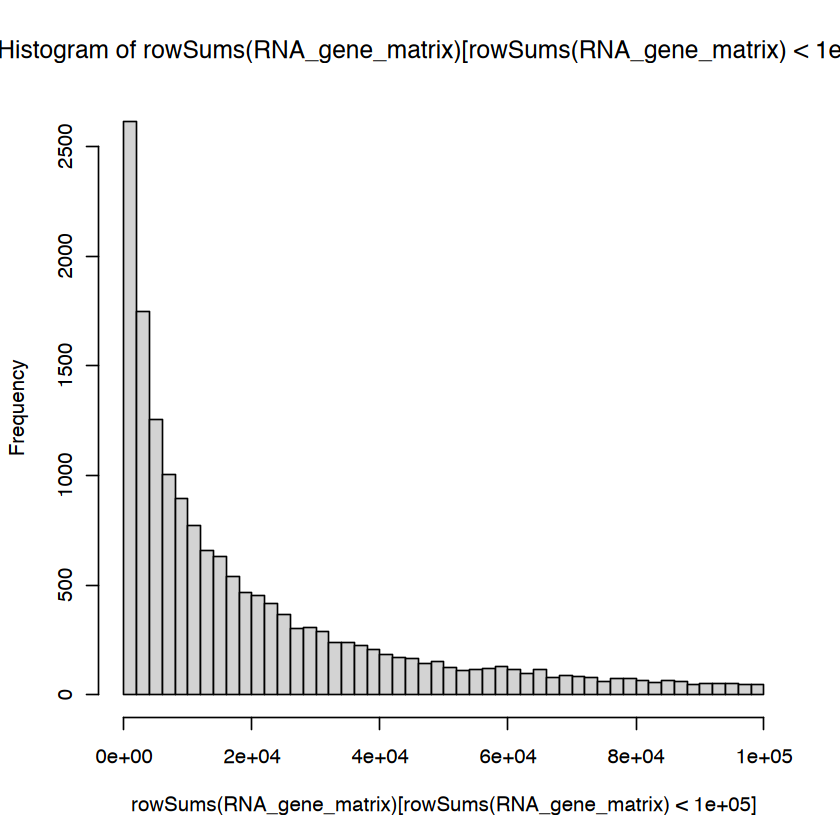

In [18]:
# check out the count distributions
hist(rowSums(RNA_gene_matrix)[rowSums(RNA_gene_matrix)<100000], breaks=40)
quantile(rowSums(RNA_gene_matrix))

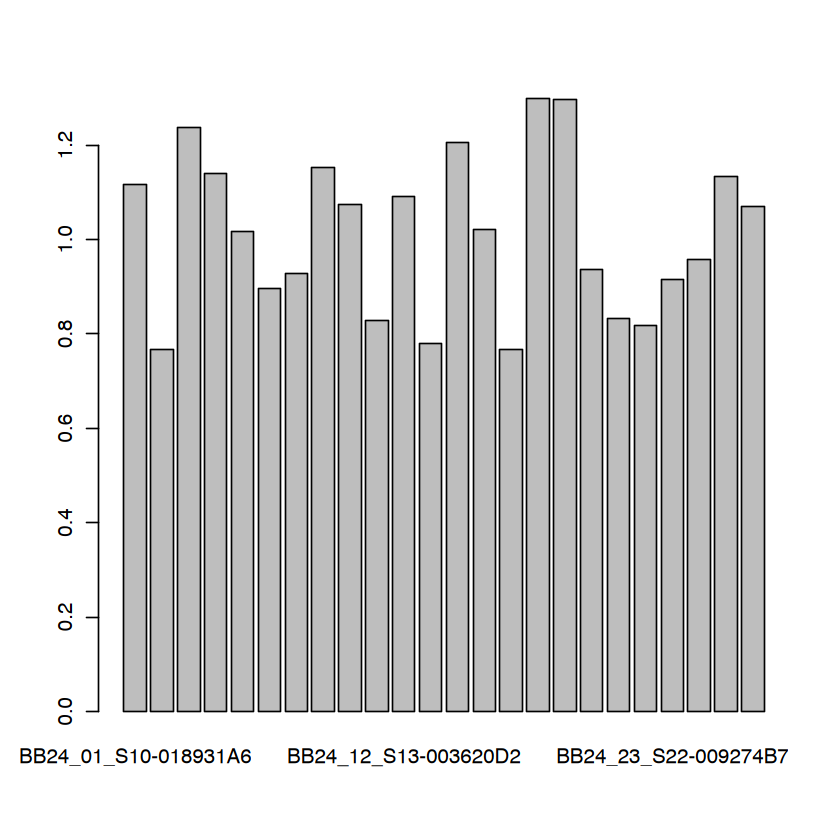

In [19]:
# create the DESeq2 objects
dds_hk <- DESeqDataSetFromMatrix(countData = RNA_hk_matrix, colData = design, 
                                    design = ~ Group + Patient)
dds_hk = estimateSizeFactors(dds_hk, type="ratio")

dds_trans <- DESeqDataSetFromMatrix(countData = RNA_matrix, colData = design, 
                                    design = ~ Group + Patient)
dds_gene <- DESeqDataSetFromMatrix(countData = RNA_gene_matrix, colData = design, 
                                    design = ~ Group + Patient)
dds_exon <- DESeqDataSetFromMatrix(countData = RNA_exon_matrix, colData = design, 
                                    design = ~ Group + Patient)
sizeFactors(dds_trans) = sizeFactors(dds_hk)
sizeFactors(dds_gene) = sizeFactors(dds_hk)
sizeFactors(dds_exon) = sizeFactors(dds_hk)
barplot(sizeFactors(dds_hk))

In [20]:
# Get the normalized counts (based on MR)
rnaseq_trans_norm <- counts(dds_trans, normalized=TRUE)
rnaseq_trans_norm[1:2,]
rnaseq_gene_norm <- counts(dds_gene, normalized=TRUE)
rnaseq_gene_norm[1:2,]
rnaseq_exon_norm <- counts(dds_exon, normalized=TRUE)
rnaseq_exon_norm[1:2,]

,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
NR_046018.2,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,1.223758,0.000,0.00000,0.00000,0.9340593
NR_024540.1,41.22928,61.35426,38.00509,38.56784,45.19511,52.48902,50.58619,44.21272,70.77165,24.11585,...,22.13861,39.25702,46.25457,39.54776,48.0734,51.397841,109.247,29.23333,77.68328,42.9667296


,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
WASH7P,41.229283,61.354257,38.00509,38.567844,45.195105,52.489019,50.58619,44.212715,70.771647,24.11585,...,22.138614,39.25702,46.254567,39.54776,48.07340,51.397841,109.24700,29.23333,77.68328,42.96673
MIR6859-1,4.481444,6.527049,0.00000,2.629626,2.947507,1.116788,0.00000,1.733832,3.724824,0.00000,...,5.209086,0.00000,5.396366,0.00000,2.40367,1.223758,5.46235,4.17619,0.00000,0.00000


,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
A2M:NM_000014.4,1501.28366,1323.68547,978.42890,1682.08394,717.2267,3914.34065,1148.41406,440.39332,2788.0304,1021.30618,...,3271.30578,506.49248,510.34206,2692.45437,1335.23864,2553.98318,2152.1658,2100.62368,601.16267,4315.35415
ADORA2A:NM_000675.5,62.74021,46.99475,25.87581,59.60485,234.8180,65.89047,39.82317,24.27365,133.1624,67.52438,...,57.29994,46.95447,23.12728,70.54466,38.45872,39.16026,54.6235,53.24643,34.42782,99.01029


## 4. For furutre comparison, get RNA-seq isoform counts based on highest expressed
* Using TPM (length-based normalization), for each gene, get the isoform that has the highest expression within the dataset
* We will use this later to see how well isoform counts focused on NanoString vs isoform counts following classic RNA-seq analysis pipelines leads to differnet results


In [21]:
# read in the gtf to link genes to isoforms
# Match up the isoforms to the hg38 pt14 gene names provided
gtf <- fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf")
gtf[1:2,]
split <- str_split_fixed(gtf$V9, ";", 3)
gtf$gene <- str_split_fixed(split[,1], '"', 3)[,2]
gtf$isoform <- str_split_fixed(split[,2], '"', 3)[,2]
gtf <- gtf[,c("gene", "isoform")]
gtf <- gtf[!duplicated(gtf),]
# only consider the isoform rows (others are gene rather than transcript)
gtf <- gtf[gtf$isoform != "",]
nrow(gtf)
gtf[1:2,]

Warning message in fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf"):
"Se detectaron 1 nombres de columnas pero los datos tienen 9 columnas (es decir, un archivo no v'alido). Se agrega/n 8 nombre(s) predeterminado(s) adicional/es de columnas al final."
Warning message in fread("~/Desktop/Clauset/assets/Refseq_GRCh38.p14.gtf"):
"Pie de p'agina de una sola l'inea descartado: <<###>>"


#!annotation-source NCBI RefSeq GCF_000001405.40-RS_2023_03,V2,V3,V4,V5,V6,V7,V8,V9
<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
chr1,BestRefSeq,gene,11874,14409,.,+,.,"gene_id ""DDX11L1""; transcript_id """"; db_xref ""GeneID:100287102""; db_xref ""HGNC:HGNC:37102""; description ""DEAD/H-box helicase 11 like 1 (pseudogene)""; gbkey ""Gene""; gene ""DDX11L1""; gene_biotype ""transcribed_pseudogene""; pseudo ""true"";"
chr1,BestRefSeq,transcript,11874,14409,.,+,.,"gene_id ""DDX11L1""; transcript_id ""NR_046018.2""; db_xref ""GeneID:100287102""; gbkey ""misc_RNA""; gene ""DDX11L1""; product ""DEAD/H-box helicase 11 like 1 (pseudogene)""; pseudo ""true""; transcript_biotype ""transcript"";"


[1] 200121

gene,isoform
<chr>,<chr>
DDX11L1,NR_046018.2
WASH7P,NR_024540.1


In [22]:
gtf <- as.data.frame(gtf)
dim(gtf)
dim(gtf[gtf$isoform %in% rnaseq_tpm$Geneid,])
# only consider genes with more than one isoform
count_df = data.table(table(gtf$gene))
count_df[1:2,]

[1] 200121      2

[1] 200121      2

V1,N
<chr>,<int>
A1BG,1
A1BG-AS1,1


In [23]:
genes_use = unique(count_df[count_df$N > 1]$V1)
length(genes_use)
isoforms_use = c()
# for each gene consider the isoforms
for (gene in genes_use) {
	# get all the isoforms for that gene
	gtf_filt = gtf[gtf$gene == gene,]
	# get the tpm counts filtered for that gene
	rnaseq_tpm_filt = rnaseq_tpm[rnaseq_tpm$Geneid %in% gtf_filt$isoform,]
	# rank by median TPM
	isoforms_use = c(isoforms_use, rnaseq_tpm_filt[order(-Median_TPM),]$Geneid[1])
}
gene_topisoform_df = data.table("Gene"=genes_use, "Top_Isoform"=isoforms_use)
gene_topisoform_df[1:4,]

[1] 24968

Gene,Top_Isoform
<chr>,<chr>
A1CF,NM_001370130.1
A2M,NM_000014.6
A2M-AS1,NR_026971.1
A2ML1,XM_017018870.2


In [24]:
# now add remaining genes
gtf_one = gtf[gtf$gene %in% count_df[count_df$N == 1]$V1,]
colnames(gtf_one) <- c("Gene", "Top_Isoform")
dim(gene_topisoform_df)
dim(gtf_one)
nrow(gene_topisoform_df) + nrow(gtf_one)
gene_topisoform_df <- rbind(gene_topisoform_df, gtf_one)
dim(gene_topisoform_df)
gene_topisoform_df[1:3,]

[1] 24968     2

[1] 24803     2

[1] 49771

[1] 49771     2

Gene,Top_Isoform
<chr>,<chr>
A1CF,NM_001370130.1
A2M,NM_000014.6
A2M-AS1,NR_026971.1


## 5. Match the Gene Names

In [25]:
# if this was already run then just read in the compare_df
compare_df_file <- "../../data/Nano_Isoform_Dict_1.19.26.txt"
if (file.exists(compare_df_file)) {
  print(paste("The file", compare_df_file, "exists."))
  compare_df <- fread(compare_df_file)
  create_compare_df = FALSE
} else {
  print(paste("The file", compare_df_file, "does not exist."))
  create_compare_df = TRUE
}

[1] "The file ../../data/Nano_Isoform_Dict_1.19.26.txt does not exist."


In [26]:
table(nano[["Analyte Type"]])
nano <- nano[nano[["Analyte Type"]] == "mRNA",]


SYSTEM   mRNA 
    14    770 

Most of the probes have annotation names of the isoforms that match exactly with that of the hg38 genome or only are different by a version number. However, some don't have a clear name linkage and instead were mapped to exons/isoforms based on BLAST. In the cases where an exon is a part of multiple isoforms, the isoform with the most exons is chosen. Below are the connections made based on BLAST and explanations as to why certain NanoString namings were not matched in the hg38 annotation

#### Connections based on BLAST:
- ALDOA: 	NM_184043.2
- CASP9: 	NM_001278054.2 or NM_001229.5
- CCL3/L1: 	NM_001001437.4
- CLECL1: NR_172486.1 or NR_172485.1
- GIMAP6: 	NM_001244072.2 or 	NM_001244072.2 or NM_024711.6 or NM_001244072.1
- IFI27: NM_001288952.2, NM_001130080.3, NM_001288956.2, NM_001288959.2, NM_001366994.1, NM_001366993.1
- IL11RA: NM_001142784.3
- IRF5: NM_001347928.2, NM_001098629.3, NM_001098630.3, NM_001242452.3, NM_032643.5, NM_001098627.4, NM_001364314.2
- KIR3DL1: NM_013289.4
- LILRA3: ONLY SCAFFOLDS
- MICA: NM_001289152.2, NM_001289153.2, NM_001289154.2, NM_001177519.3
- P2RY13: NM_176894.3
- P4HA2: NM_001365681.2, NM_001365677.2, NM_001017974.2, NM_001142599.2, NM_001142598.2, NM_001365680.2, NM_001365678.2, NM_001365679.2, NM_004199.3
- TLR4: NM_003266.4, NM_138554.5, NM_138557.3
- WNT11: NM_004626.3
  
#### Explanation of NanoString isoform namings with no matches to the hg38 annotation
1.  NM_000034.3: This RefSeq was removed because the transcript represents a separate adjacent gene (ALDOA)
2. XM_011542270.1: This record was removed as a result of standard genome annotation processing. Please see www.ncbi.nlm.nih.gov/genome/annotation_euk/process/ for more information.
3. **NM_021006.5** --> NM_021006.6
3. ENST00000367367.1 (PTPRC)
4. NM_172004.3: This RefSeq was removed because it is now thought that this gene is a pseudogene.
5. NR_024115.1: Has been replaced by NM_001244071 (NM_001244071.2)
6. NM_005532.3: This sequence has been updated: NM_005532.5: This RefSeq was removed because the 9-nt deletion in the transcript, resulting in a 3-aa deletion in the protein, is not present in the reference genome.
7. NM_147162.1: This RefSeq was permanently suppressed because it is a nonsense-mediated mRNA decay (NMD) candidate.
8. NM_002200.3: This sequence has been replaced by NM_001098629 (NM_001098629.3)
9. **NM_001322168.1**: Exists and should be found on chromosome 19
10. **NM_001322168.1**: Exists so not sure why not found
11. **NM_001172654.2**: Exists so not sure why not found
12. **NM_000247.1**: Updated to NM_000247.3
9. NM_023914.2: This RefSeq was permanently suppressed because currently there is insufficient support for the transcript, which appears to include intronic sequence.
10. NM_001017973.1: This sequence has been replaced by NM_001365679 (NM_001365679.2)
11. NR_024168.1: This sequence has been replaced by NM_003266 (NM_003266.4)
12. XM_011545241.2: This record was removed as a result of standard genome annotation processing. Please see www.ncbi.nlm.nih.gov/genome/annotation_euk/process/ for more information.

In [27]:
# Get the transcripts that originally have no linkage but can be mapped via BLAST
blast_dict = list("ALDOA:NM_000034.3"="NM_184043.2", "CASP9:XM_011542270.1"="NM_001278054.2", 
            "CCL3/L1:NM_021006.5"="NM_001001437.4",  
            "CLECL1:NM_172004.3"="NR_172486.1", "GIMAP6:NR_024115.1"="NM_001244072.2", 
            "IFI27:NM_005532.3"="NM_001288952.2", "IL11RA:NM_147162.1"="NM_001142784.3", 
            "IRF5:NM_002200.3"="NM_001347928.2", "KIR3DL1:NM_001322168.1"="NM_013289.4", 
            "MICA:NM_000247.1"="NM_001289152.2", "P2RY13:NM_023914.2"="NM_176894.3", 
            "P4HA2:NM_001017973.1"="NM_001365681.2", "TLR4:NR_024168.1"="NM_138554.5", 
            "WNT11:XM_011545241.2"="NM_004626.3")

In [28]:
# Get comparable naming conventions
nano$Geneid <- paste0(nano[["Probe Name"]], ":", nano[["Accession #"]])
rnaseq$Gene_Acc <- str_split_fixed(rnaseq$Geneid, "[.]", 2)[,1]
# remove any rnaseq calls that consider non primary chromosomes
rnaseq[1:3,]
rnaseq_clean <- rnaseq[grep("chr", rnaseq$Chr),]
dim(rnaseq)
dim(rnaseq_clean)

Geneid,Chr,Start,End,Strand,Length,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,...,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538,Gene_Acc
<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<chr>
NR_046018.2,chr1;chr1;chr1,11874;12613;13221,12227;12721;14409,+;+;+,1652,0,0,0,0,...,0,0,0,0,1,0,0,0,1,NR_046018
NR_024540.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14362;14970;15796;16607;16858;17233;17606;17915;18268;24738;29321,14829;15038;15947;16765;17055;17368;17742;18061;18366;24891;29370,-;-;-;-;-;-;-;-;-;-;-,1769,46,47,47,44,...,51,60,37,40,42,100,28,88,46,NR_024540
NR_106918.1,chr1,17369,17436,-,68,5,5,0,3,...,0,7,0,2,1,5,4,0,0,NR_106918


[1] 200121     31

[1] 180322     31

In [29]:
if (create_compare_df) {
	# for each nanostring transcript, get the matching RNAseq isoform equivlanet
	rna_equiv = c()
	dups = 0
	nones = 0
	equivs = 0
	idents = 0
	for (nano_gene_trans in unique(nano$Geneid)) {
		nano_trans = str_split_fixed(nano_gene_trans, ":", 2)[,2]
		# first see if the exact matches
		rna_equiv_check = rnaseq_clean[rnaseq_clean$Geneid == nano_trans,]$Geneid
		if (length(rna_equiv_check) > 0) {
			rna_equiv = c(rna_equiv, rna_equiv_check)
			idents = idents + 1
			} else {
		# see if can find nonduplicated original (just different value)
		gene_acc = str_split_fixed(nano_trans, "[.]", 2)[,1]
		rna_equiv_check = rnaseq_clean[rnaseq_clean$Gene_Acc == gene_acc,]$Geneid
		if (length(rna_equiv_check) > 1) {
			cat("\nDuplicate so hand check", nano_gene_trans, "\tRNAs:", rna_equiv_check)
			rna_equiv = c(rna_equiv, "Duplicate")
			dups = dups + 1
			} else if (length(rna_equiv_check) == 1) {
			rna_equiv = c(rna_equiv, rna_equiv_check)
			equivs = equivs + 1
			} else {
			# get blast equivalent
			blast_check = blast_dict[[nano_gene_trans]]
			if (length(blast_check) != 0) {
				rna_equiv = c(rna_equiv, blast_check)
				} else {
				rna_equiv = c(rna_equiv, "None")
				nones = nones+1
				}
			
			}
		}
		}
	cat("\nNumber identical matches:", idents, "\tNumber equiv but not identical found:", equivs, "\tNumber of Dups:", dups, "\tNumber of Nones:", nones)
	compare_df = data.table("Nano"= unique(nano$Geneid), "RNA"=rna_equiv)

	
}

compare_df[1:2,]


Number identical matches: 31 	Number equiv but not identical found: 723 	Number of Dups: 0 	Number of Nones: 2

Nano,RNA
<chr>,<chr>
A2M:NM_000014.4,NM_000014.6
ACVR1C:NM_145259.2,NM_145259.3


### Note on CD45RA and CD45RB and PTPRC
The CD45RA/B genes no longer exist and therefore we are considering different genes:
Since there is overlap in transcripts, I have chosen ones specific to them 
All from BLAST:
* PTPRC (198639067 to 198639137): **NM_002838.5** or NM_080921.4, NM_001267798.2 or **XM_006711472.5** or XM_006711473.4 or XM_00671173. or XM_006711474.4 or NR_052021.2
* CD45RA (198696708 to 198696756): **NM_002838.5** or **XM_047426381.1**, **XM_006711472.5**
* CD45RB (198699563 to 198699608): **NM_002838.5** or **XM_047426381.1**, XM_047426398.1, XM_047426409.1, **XM_006711472.5**, XM_006711473.4, XM_006711474.4
* CD45RO (198703297 to 198703342): **NM_002838.5** or **XM_047426381.1** or XM_047426398.1 or XM_047426409.1 or XM_047426415.1 or NM_080921.4 or **XM_006711472.5** or XM_006711473.4 or XM_006711474.4.

Final assignments:
PTPRC: NM_080921.4 (what assigned to originally)
CD45RA: NM_002838.5
CD45RB: XM_047426398.1
CD45RO: XM_006711472.5

In [30]:
if (create_compare_df) {
	compare_df[compare_df$RNA == "None",]
	dim(compare_df)
	length(unique(compare_df$Nano))
	length(unique(compare_df$RNA))

	compare_df[compare_df$RNA %in% compare_df$RNA[duplicated(compare_df$RNA)],]
	nano[nano$Geneid %in% compare_df[compare_df$RNA %in% compare_df$RNA[duplicated(compare_df$RNA)],]$Nano,]

	# noting what I did above
	compare_df[compare_df$Nano == "CD45RO:NM_080921.3",]$RNA <- "XM_006711472.5"
	compare_df[compare_df$Nano == "CD45RB:ENST00000367367.1",]$RNA <- "XM_047426398.1"
	# adding LILRA3 back (on noncanonical chromosome but maps in BLAST too with no primary equivalent)
	compare_df[compare_df$Nano == "LILRA3:NM_001172654.2",]$RNA <- "NM_001172654.2"
}



In [32]:
if (create_compare_df) {
# only consider GTF where isoform we care about
gtf <- gtf[gtf$isoform %in% compare_df$RNA,]
nrow(gtf)
gtf = gtf[order(gtf$isoform),]
compare_df = compare_df[order(compare_df$RNA),]
identical(gtf$isoform, compare_df$RNA)

compare_df$hg38pt14_Gene <- gtf$gene
compare_df[1:2,]

}

Nano,RNA,hg38pt14_Gene
<chr>,<chr>,<chr>
A2M:NM_000014.4,NM_000014.6,A2M
APOE:NM_000041.2,NM_000041.4,APOE


### 4B. Compare the NanoString isoforms with the Top Isoform in RNA-seq

In [33]:
if (create_compare_df) {
	gene_topisoform_df_filt = gene_topisoform_df[gene_topisoform_df$Gene %in% compare_df$hg38pt14_Gene,]
	compare_df <- merge(compare_df, gene_topisoform_df_filt, by.x="hg38pt14_Gene", by.y="Gene")
	compare_df$Match <- "No"
	compare_df[compare_df$RNA == compare_df$Top_Isoform,]$Match <- "Yes"
	table(compare_df$Match)
	# save the compare_df for later usage
	dim(compare_df)
	compare_df[1:2,]
	write.table(compare_df, compare_df_file, 
				quote=FALSE, row.names=FALSE)
}


In most cases, a different isoform is being used

## 5. Now get matrices with the simple gene names
THe isoforms will still be consistent but we will use the simpler gene names for easier interpretation

### 5A. Get the Isoforms matching to Nanostring with simple names

In [33]:
# double check that all isoforms are accounted for 
setdiff(compare_df$RNA, rnaseq$Geneid)
setdiff(compare_df$RNA, rnaseq_rpkm$Geneid)
setdiff(compare_df$RNA, rnaseq_tpm$Geneid)

character(0)

character(0)

character(0)

In [34]:
rnaseq_exon_tpm[1:2,]

Geneid,BB24_01_S10-018931A6_TPM,BB24_02_S14-002474B2_TPM,BB24_03_S21-024801A2_TPM,BB24_04_S10-016783A2_TPM,BB24_06_S10-016752C1_TPM,BB24_07_S10-017623A2_TPM,BB24_08_S11-003355A1_TPM,BB24_09_S11-012085C1_TPM,BB24_10_S12-003590C5_TPM,...,BB24_18_S13-009885J1_TPM,BB24_19_S17-018143A2_TPM,BB24_20_S13-019142C2_TPM,BB24_21_S13-021353A4_TPM,BB24_22_S14-012409D2_TPM,BB24_23_S22-009274B7_TPM,BB24_24_S21-028943A10_TPM,BB24_25_S11-011709_TPM,BB24_26_S12-011538_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M:NM_000014.4,1182.903677,974.366318,950.508644,1331.294769,480.99342,2800.595580,889.519018,374.920538,1461.294324,...,465.719594,460.474401,1862.182443,1032.867261,1694.523608,1518.151517,1703.720970,541.180594,3121.414706,1107.885469
ADORA2A:NM_000675.5,4.008225,2.804829,2.038169,3.824967,12.76832,3.822381,2.500991,1.675533,5.659023,...,3.500644,1.691953,3.956011,2.412126,2.106661,3.124197,3.501549,2.512923,5.806774,3.501097


In [35]:
# Get ALL counts to be matrices with Geneids to be rownames instead
# (MR based normalized data is already in this format)
rnaseq_tpm[1:2,]
rnaseq_trans_norm[1:2,]
rnaseq_exon_norm[1:2,]

# Transcripts TPM
colnames(rnaseq_tpm) <- gsub("_TPM", "", colnames(rnaseq_tpm))
rnaseq_tpm_final = as.matrix(as.data.frame(rnaseq_tpm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_tpm_final) <- rnaseq_tpm$Geneid
colnames(rnaseq_exon_tpm) <- gsub("_TPM", "", colnames(rnaseq_exon_tpm))
rnaseq_exon_tpm_final = as.matrix(as.data.frame(rnaseq_exon_tpm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_exon_tpm_final) <- rnaseq_exon_tpm$Geneid
rnaseq_tpm <- rnaseq_tpm_final
rm(rnaseq_exon_tpm)
# Transcripts RPKM
colnames(rnaseq_rpkm) <- gsub("_RPKM", "", colnames(rnaseq_rpkm))
rnaseq_rpkm_final = as.matrix(as.data.frame(rnaseq_rpkm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_rpkm_final) <- rnaseq_rpkm$Geneid
colnames(rnaseq_exon_rpkm) <- gsub("_RPKM", "", colnames(rnaseq_exon_rpkm))
rnaseq_exon_rpkm_final = as.matrix(as.data.frame(rnaseq_exon_rpkm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_exon_rpkm_final) <- rnaseq_exon_rpkm$Geneid
rnaseq_rpkm <- rnaseq_rpkm_final
rm(rnaseq_exon_rpkm)


Geneid,BB24_01_S10-018931A6_TPM,BB24_02_S14-002474B2_TPM,BB24_03_S21-024801A2_TPM,BB24_04_S10-016783A2_TPM,BB24_06_S10-016752C1_TPM,BB24_07_S10-017623A2_TPM,BB24_08_S11-003355A1_TPM,BB24_09_S11-012085C1_TPM,BB24_10_S12-003590C5_TPM,...,BB24_18_S13-009885J1_TPM,BB24_19_S17-018143A2_TPM,BB24_20_S13-019142C2_TPM,BB24_21_S13-021353A4_TPM,BB24_22_S14-012409D2_TPM,BB24_23_S22-009274B7_TPM,BB24_24_S21-028943A10_TPM,BB24_25_S11-011709_TPM,BB24_26_S12-011538_TPM,Median_TPM
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
NR_046018.2,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.00000,0.000000,0.00000,0.000000,0.07077463,0.000000,0.000000,0.000000,0.05889277,0.000000
NR_024540.1,2.644399,3.67635,3.005406,2.484772,2.467225,3.056996,3.189505,3.063941,3.019494,...,2.93835,3.397296,2.22654,3.027088,2.77593392,6.273119,1.930026,5.692623,2.52989203,2.857142


,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
NR_046018.2,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.0000,1.223758,0.000,0.00000,0.00000,0.9340593
NR_024540.1,41.22928,61.35426,38.00509,38.56784,45.19511,52.48902,50.58619,44.21272,70.77165,24.11585,...,22.13861,39.25702,46.25457,39.54776,48.0734,51.397841,109.247,29.23333,77.68328,42.9667296


,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
A2M:NM_000014.4,1501.28366,1323.68547,978.42890,1682.08394,717.2267,3914.34065,1148.41406,440.39332,2788.0304,1021.30618,...,3271.30578,506.49248,510.34206,2692.45437,1335.23864,2553.98318,2152.1658,2100.62368,601.16267,4315.35415
ADORA2A:NM_000675.5,62.74021,46.99475,25.87581,59.60485,234.8180,65.89047,39.82317,24.27365,133.1624,67.52438,...,57.29994,46.95447,23.12728,70.54466,38.45872,39.16026,54.6235,53.24643,34.42782,99.01029


In [36]:
dim(nano)
nano[1:2,]

[1] 770  37

Probe Name,Annotation,Accession #,NS Probe ID,Class Name,Analyte Type,Target Sequence,% Samples above Threshold,Positive Flag,Avg Count,...,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7,Geneid
<chr>,<lgl>,<chr>,<lgl>,<chr>,<chr>,<lgl>,<dbl>,<lgl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
A2M,NA,NM_000014.4,NA,Endogenous,mRNA,NA,100,FALSE,2666.47,...,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64,A2M:NM_000014.4
ACVR1C,NA,NM_145259.2,NA,Endogenous,mRNA,NA,100,FALSE,67.27,...,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33,ACVR1C:NM_145259.2


In [37]:
# for the transcript based counts, only keep the isoforms mapped to their relevant NanoString gene
# nano
nano <- as.data.frame(nano)
rownames(nano) <- paste0(nano[["Probe Name"]], ":", nano[["Accession #"]])
# raw
rnaseq_final <- as.data.frame(rnaseq[rnaseq$Geneid %in% compare_df$RNA,])
rownames(rnaseq_final) <- rnaseq_final$Geneid
# RPKM, TPM, MR -- RNA-seq based isoforms
rnaseq_rpkm_final_ri <- as.data.frame(rnaseq_rpkm_final[rownames(rnaseq_rpkm_final) %in% compare_df$Top_Isoform,])
rnaseq_tpm_final_ri <- as.data.frame(rnaseq_tpm_final[rownames(rnaseq_tpm_final) %in% compare_df$Top_Isoform,])
rnaseq_norm_final_ri <- as.data.frame(rnaseq_trans_norm[rownames(rnaseq_trans_norm) %in% compare_df$Top_Isoform,])

# RPKM, TPM, MR -- NanoString based isoforms
rnaseq_rpkm_final <- as.data.frame(rnaseq_rpkm_final[rownames(rnaseq_rpkm_final) %in% compare_df$RNA,])
rnaseq_exon_tpm <-as.data.frame(rnaseq_exon_rpkm_final[rownames(rnaseq_exon_rpkm_final) %in% compare_df$Nano,])
rnaseq_tpm_final <- as.data.frame(rnaseq_tpm_final[rownames(rnaseq_tpm_final) %in% compare_df$RNA,])
rnaseq_exon_tpm_final <- as.data.frame(rnaseq_exon_tpm_final[rownames(rnaseq_exon_tpm_final) %in% compare_df$Nano,])
rnaseq_norm_final <- as.data.frame(rnaseq_trans_norm[rownames(rnaseq_trans_norm) %in% compare_df$RNA,])
rnaseq_exon_norm_final <- as.data.frame(rnaseq_exon_norm[rownames(rnaseq_exon_norm) %in% compare_df$Nano,])

dim(rnaseq_norm_final)
dim(rnaseq_norm_final_ri)
dim(rnaseq_exon_norm_final)
dim(rnaseq_final)
dim(rnaseq_tpm_final)
dim(rnaseq_tpm_final_ri)
dim(rnaseq_exon_tpm_final)
dim(rnaseq_rpkm_final)
dim(rnaseq_rpkm_final_ri)
dim(rnaseq_exon_rpkm_final)
dim(nano)

[1] 770  24

[1] 767  24

[1] 765  24

[1] 770  31

[1] 770  24

...

[1] 765  24

[1] 770  24

[1] 767  24

[1] 765  24

[1] 770  37

In [38]:
setdiff(rownames(nano), compare_df$Nano)
setdiff(rownames(rnaseq_exon_norm), compare_df$Nano)

character(0)

character(0)

In [39]:
# Get the gene names from NanoString (for easier saving)
compare_df$Nano_Gene <- str_split_fixed(compare_df$Nano, ":", 2)[,1]
compare_df[1:2,]
# cases where hg38pt14 gene name is different from the nanostring gene name
compare_df[compare_df$Nano_Gene != compare_df$hg38pt14_Gene,]

hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Nano_Gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
A2M,A2M:NM_000014.4,NM_000014.6,NM_000014.6,Yes,A2M
ABCF1,ABCF1:NM_001090.2,NM_001090.3,NM_001025091.2,No,ABCF1


hg38pt14_Gene,Nano,RNA,Top_Isoform,Match,Nano_Gene
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
CCL3L3,CCL3/L1:NM_021006.5,NM_001001437.4,NM_001001437.4,Yes,CCL3/L1
CGAS,MB21D1:NM_138441.2,NM_138441.3,NM_001410911.1,No,MB21D1
CLECL1P,CLECL1:NM_172004.3,NR_172486.1,NR_172486.1,Yes,CLECL1
DIPK2B,CXorf36:NM_024689.2,NM_024689.3,NM_024689.3,Yes,CXorf36
FCGR3B,FCGR3A/B:NM_000570.4,NM_000570.5,NM_001271035.2,No,FCGR3A/B
H2AX,H2AFX:NM_002105.2,NM_002105.3,NM_002105.3,Yes,H2AFX
IFT70A,TTC30A:NM_152275.3,NM_152275.4,NM_152275.4,Yes,TTC30A
MAGEA3,MAGEA3/A6:NM_005362.3,NM_005362.4,XM_006724818.3,No,MAGEA3/A6
PTPRC,CD45RA:NM_002838.4,NM_002838.5,XM_047426415.1,No,CD45RA


In [40]:
rnaseq_final[1:2, 7:(ncol(rnaseq_final)-1)]
nano[1:2, 13:(ncol(nano)-1)]

,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,...,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
NM_005101.4,163,62,202,438,122,167,667,875,1038,108,...,482,225,407,378,93,123,112,83,424,63
NM_148901.2,15,14,22,57,77,9,22,11,50,45,...,38,32,18,40,12,34,30,19,13,7


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M:NM_000014.4,809.80,2592.88,5996.73,2242.26,1393.15,936.59,2802.52,6399.68,3603.75,1575.61,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C:NM_145259.2,49.63,52.61,27.54,16.85,28.05,166.86,29.79,22.72,25.50,38.56,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


In [41]:
# Get the actual rownames assigned for the dataframes currently not matrices
tmp <- as.matrix(nano[, 13:(ncol(nano)-1)])
rownames(tmp) <- rownames(nano)
nano <- tmp
tmp <- as.matrix(rnaseq_final[, 7:(ncol(rnaseq_final)-1)])
rownames(tmp) <- rnaseq_final$Geneid
rnaseq_final <- tmp
nano[1:2,]
rnaseq_final[1:2,]

,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
A2M:NM_000014.4,809.80,2592.88,5996.73,2242.26,1393.15,936.59,2802.52,6399.68,3603.75,1575.61,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ACVR1C:NM_145259.2,49.63,52.61,27.54,16.85,28.05,166.86,29.79,22.72,25.50,38.56,...,52.57,23.59,50.49,30.45,26.06,27.62,345.39,22.63,38.03,28.33


,BB24_01_S10-018931A6,BB24_02_S14-002474B2,BB24_03_S21-024801A2,BB24_04_S10-016783A2,BB24_06_S10-016752C1,BB24_07_S10-017623A2,BB24_08_S11-003355A1,BB24_09_S11-012085C1,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_17_S21-032280A2,BB24_18_S13-009885J1,BB24_19_S17-018143A2,BB24_20_S13-019142C2,BB24_21_S13-021353A4,BB24_22_S14-012409D2,BB24_23_S22-009274B7,BB24_24_S21-028943A10,BB24_25_S11-011709,BB24_26_S12-011538
NM_005101.4,163,62,202,438,122,167,667,875,1038,108,...,482,225,407,378,93,123,112,83,424,63
NM_148901.2,15,14,22,57,77,9,22,11,50,45,...,38,32,18,40,12,34,30,19,13,7


In [42]:
# get them in the same order before having unified gene names
nano <- nano[compare_df$Nano,]
rnaseq_final <- rnaseq_final[compare_df$RNA,]
rnaseq_norm_final <- rnaseq_norm_final[compare_df$RNA,]
rnaseq_norm_final_ri <- rnaseq_norm_final_ri[compare_df$Top_Isoform,]
rnaseq_tpm_final <- rnaseq_tpm_final[compare_df$RNA,]
rnaseq_tpm_final_ri <- rnaseq_tpm_final_ri[compare_df$Top_Isoform,]
rnaseq_rpkm_final <- rnaseq_rpkm_final[compare_df$RNA,]
rnaseq_rpkm_final_ri <- rnaseq_rpkm_final_ri[compare_df$Top_Isoform,]

rownames(nano) <- compare_df$Nano_Gene
rownames(rnaseq_final) <- compare_df$Nano_Gene
rownames(rnaseq_norm_final) <- compare_df$Nano_Gene
rownames(rnaseq_norm_final_ri) <- compare_df$Nano_Gene
rownames(rnaseq_tpm_final) <- compare_df$Nano_Gene
rownames(rnaseq_tpm_final_ri) <- compare_df$Nano_Gene
rownames(rnaseq_rpkm_final) <- compare_df$Nano_Gene
rownames(rnaseq_rpkm_final_ri) <- compare_df$Nano_Gene

# get them to have the same column order
rnaseq_final <- rnaseq_final[, colnames(nano)]
rnaseq_norm_final <- rnaseq_norm_final[, colnames(nano)]
rnaseq_norm_final_ri <- rnaseq_norm_final_ri[, colnames(nano)]
rnaseq_tpm_final <- rnaseq_tpm_final[, colnames(nano)]
rnaseq_tpm_final_ri <- rnaseq_tpm_final_ri[, colnames(nano)]
rnaseq_rpkm_final <- rnaseq_rpkm_final[, colnames(nano)]
rnaseq_rpkm_final_ri <- rnaseq_rpkm_final_ri[, colnames(nano)]


In [43]:
rnaseq_tpm_final_ri[1:2,]


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,286.06281,817.1576,1723.2314,686.8012,369.2938,220.96791,657.3710,1693.642,920.87098,398.5931,...,260.6155,948.064,558.7989,299.5341,729.97521,325.7382,619.1330,1085.92071,1298.90395,945.71293
ABCF1,94.54651,116.3583,100.6312,105.9653,133.3223,90.95162,148.0763,103.634,89.12795,117.6473,...,129.0094,122.036,106.3084,211.4401,94.86549,162.2033,118.8657,94.00375,90.50655,88.41869


In [44]:
compare_df_exononly = compare_df[compare_df$Nano %in% rownames(rnaseq_exon_norm_final),]

rnaseq_exon_norm_final <- rnaseq_exon_norm_final[compare_df_exononly$Nano,]
rnaseq_exon_tpm_final <- rnaseq_exon_tpm_final[compare_df_exononly$Nano,]
rnaseq_exon_rpkm_final <- rnaseq_exon_rpkm_final[compare_df_exononly$Nano,]

rownames(rnaseq_exon_norm_final) <- compare_df_exononly$Nano_Gene
rownames(rnaseq_exon_tpm_final) <- compare_df_exononly$Nano_Gene
rownames(rnaseq_exon_rpkm_final) <- compare_df_exononly$Nano_Gene

# get them to have the same column order
rnaseq_exon_norm_final <- rnaseq_exon_norm_final[, colnames(nano)]
rnaseq_exon_tpm_final <- rnaseq_exon_tpm_final[, colnames(nano)]
rnaseq_exon_rpkm_final <- rnaseq_exon_rpkm_final[, colnames(nano)]


In [45]:
setdiff(colnames(rnaseq_final), colnames(nano))
setdiff(colnames(nano), colnames(rnaseq_final))
setdiff(colnames(rnaseq_norm_final), colnames(rnaseq_final))
setdiff(colnames(rnaseq_norm_final), colnames(nano))

character(0)

character(0)

character(0)

character(0)

In [46]:
# ensure all look as expected
rnaseq_final[1:2,]
nano[1:2,]
rnaseq_norm_final[1:2,]
rnaseq_tpm_final[1:2,]
rnaseq_rpkm_final[1:2,]
rnaseq_norm_final_ri[1:2,]
rnaseq_tpm_final_ri[1:2,]
rnaseq_rpkm_final_ri[1:2,]
rnaseq_exon_norm_final[1:2,]
rnaseq_exon_tpm_final[1:2,]
rnaseq_exon_rpkm_final[1:2,]

,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
A2M,13899,37709,69043,31134,14877,9585,25244,80251,60402,16128,...,11788,37381,18617,14918,34296,14992,25232,41055,49664,39287
ABCF1,3261,3776,2820,3419,3839,2818,4013,3471,4126,3337,...,4100,3398,2472,7425,3146,5308,3421,2528,2473,2607


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
A2M,809.80,2592.88,5996.73,2242.26,1393.15,936.59,2802.52,6399.68,3603.75,1575.61,...,1224.49,3863.67,1730.37,1046.32,2451.99,1067.39,1835.93,3185.74,4913.43,3370.64
ABCF1,318.35,354.90,324.02,278.32,467.50,366.02,335.11,338.16,350.36,404.00,...,378.20,377.52,301.02,612.97,300.73,473.85,432.96,294.19,313.71,280.95


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,13655.80,33053.519,77106.368,27905.054,13132.888,8309.390,27170.163,74959.20,56246.698,19447.020,...,9073.759,45745.30,24302.813,12376.397,33606.212,11557.475,20403.073,42863.372,64676.007,42919.867
ABCF1,3203.94,3309.822,3149.341,3064.411,3388.933,2442.969,4319.199,3242.12,3842.155,4023.729,...,3155.956,4158.33,3226.973,6159.991,3082.725,4091.987,2766.285,2639.352,3220.517,2848.069


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,286.06281,817.1576,1723.231,686.8012,369.2938,220.96791,657.3710,1693.6416,920.87098,398.5931,...,260.6155,948.0640,558.7989,299.5341,729.97521,325.7382,619.1330,1085.92071,1298.9040,945.71293
ABCF1,94.01598,114.6214,98.593,105.6497,133.4897,91.00204,146.3843,102.6121,88.11498,115.5257,...,126.9747,120.7211,103.9363,208.8359,93.79861,161.5523,117.5867,93.66604,90.6009,87.90722


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,89.60131,218.23287,447.00351,178.11755,101.15415,61.43819,165.58370,417.36910,311.14774,112.57733,...,79.12803,230.62686,139.12906,79.16048,190.5808,90.75802,172.44173,285.00424,365.78679,265.74752
ABCF1,29.44792,30.61119,25.57487,27.39958,36.56449,25.30232,36.87242,25.28701,29.77266,32.62869,...,38.55202,29.36672,25.87794,55.19088,24.4888,45.01211,32.75042,24.58303,25.51429,24.70213


...

,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,286.06281,817.1576,1723.2314,686.8012,369.2938,220.96791,657.3710,1693.642,920.87098,398.5931,...,260.6155,948.064,558.7989,299.5341,729.97521,325.7382,619.1330,1085.92071,1298.90395,945.71293
ABCF1,94.54651,116.3583,100.6312,105.9653,133.3223,90.95162,148.0763,103.634,89.12795,117.6473,...,129.0094,122.036,106.3084,211.4401,94.86549,162.2033,118.8657,94.00375,90.50655,88.41869


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,89.60131,218.23287,447.00351,178.11755,101.15415,61.43819,165.5837,417.36910,311.14774,112.57733,...,79.12803,230.62686,139.12906,79.16048,190.58082,90.75802,172.44173,285.00424,365.78679,265.74752
ABCF1,29.61410,31.07504,26.10356,27.48142,36.51862,25.28830,37.2986,25.53884,30.11492,33.22792,...,39.16980,29.68658,26.46852,55.87912,24.76734,45.19351,33.10662,24.67166,25.48772,24.84586


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,717.2267,1682.0839,3914.341,1501.2837,601.1627,440.3933,1148.414,4315.3541,2788.0304,1021.306,...,506.4925,2553.9832,1323.6855,667.0213,1835.3288,510.3421,978.4289,2100.6237,3271.3058,2152.1658
ABCF1,264.2931,284.8761,215.540,270.6792,265.7121,180.3185,317.509,325.0527,349.2022,389.471,...,234.0026,353.6661,207.5601,424.7698,318.4633,383.1420,201.3461,223.4262,265.6634,258.9154


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,...,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A2M,480.9934,1331.2948,2800.59558,1182.9037,541.1806,374.92054,889.5190,3121.4147,1461.2943,670.1485,...,465.7196,1694.5236,974.36632,516.8090,1276.2650,460.4744,950.5086,1703.7210,2103.2622,1518.1515
ABCF1,112.9335,143.6603,98.25932,135.8925,152.4108,97.81217,156.6992,149.8107,116.6195,162.8337,...,137.0965,149.5124,97.34989,209.6998,141.1044,220.2713,124.6304,115.4618,108.8323,116.3727


,BB24_06_S10-016752C1,BB24_04_S10-016783A2,BB24_07_S10-017623A2,BB24_01_S10-018931A6,BB24_25_S11-011709,BB24_09_S11-012085C1,BB24_08_S11-003355A1,BB24_26_S12-011538,BB24_10_S12-003590C5,BB24_11_S12-008138A2,...,BB24_18_S13-009885J1,BB24_22_S14-012409D2,BB24_02_S14-002474B2,BB24_15_S16-023867D1,BB24_16_S16-007066C1,BB24_19_S17-018143A2,BB24_03_S21-024801A2,BB24_24_S21-028943A10,BB24_17_S21-032280A2,BB24_23_S22-009274B7
A2M,150.6580,355.5401,726.47009,306.77858,148.2361,104.24337,224.05893,769.21943,493.74824,189.27457,...,141.4017,412.2113,242.59651,136.5816,333.20533,128.29859,264.73692,447.14840,592.30362,426.60410
ABCF1,35.3733,38.3664,25.48831,35.24287,41.7472,27.19582,39.47062,36.91829,39.40389,45.99021,...,41.6252,36.3705,24.23806,55.4192,36.83932,61.37257,34.71223,30.30341,30.64848,32.70101


In [52]:
write.table(rnaseq_final, "../data/final_counts/RNA_raw_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(nano, "../data/final_counts/Nano_norm_10.2.25.csv", 
            quote=FALSE, sep=",")

write.table(rnaseq_norm_final, "../data/final_counts/RNA_norm_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_tpm_final, "../data/final_counts/RNA_TPM_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_rpkm_final, "../data/final_counts/RNA_RPKM_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")

write.table(rnaseq_norm_final_ri, "../data/final_counts/RNA_norm_Nanogenes_RNAIsof_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_tpm_final_ri, "../data/final_counts/RNA_TPM_Nanogenes_RNAIsof_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_rpkm_final_ri, "../data/final_counts/RNA_RPKM_Nanogenes_RNAIsof_10.2.25.csv", 
            quote=FALSE, sep=",")

write.table(rnaseq_exon_norm_final, "../data/final_counts/RNA_exon_norm_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_exon_tpm_final, "../data/final_counts/RNA_exon_TPM_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")
write.table(rnaseq_exon_rpkm_final, "../data/final_counts/RNA_exon_RPKM_Nanogenes_10.2.25.csv", 
            quote=FALSE, sep=",")



### 5B. Get the full gene counts (not just NanoString) too

In [47]:
# Get the matrix format for the Gene matrices
colnames(rnaseq_gene_tpm) <- gsub("_TPM", "", colnames(rnaseq_gene_tpm))
rnaseq_gene_tpm_final = as.matrix(as.data.frame(rnaseq_gene_tpm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_gene_tpm_final) <- rnaseq_gene_tpm$Geneid
rm(rnaseq_gene_tpm)

colnames(rnaseq_gene_rpkm) <- gsub("_RPKM", "", colnames(rnaseq_gene_rpkm))
rnaseq_gene_rpkm_final = as.matrix(as.data.frame(rnaseq_gene_rpkm)[, colnames(rnaseq_trans_norm)])
rownames(rnaseq_gene_rpkm_final) <- rnaseq_gene_rpkm$Geneid
rm(rnaseq_gene_rpkm)

In [48]:
# What genes are in full that should be removed since Nano
length(intersect(rownames(nano), rownames(rnaseq_gene_norm)))
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_norm)))
dim(rnaseq_gene_norm)
dim(rnaseq_gene_tpm_final)
dim(rnaseq_gene_rpkm_final)
rnaseq_gene_norm <- subset(rnaseq_gene_norm, !rownames(rnaseq_gene_norm) %in% compare_df$hg38pt14_Gene)
rnaseq_gene_tpm_final <- subset(rnaseq_gene_tpm_final, rownames(rnaseq_gene_tpm_final) %in% rownames(rnaseq_gene_norm))
rnaseq_gene_rpkm_final <- subset(rnaseq_gene_rpkm_final, rownames(rnaseq_gene_rpkm_final) %in% rownames(rnaseq_gene_norm))
rnaseq_topisof_tpm_final <- subset(rnaseq_tpm, !rownames(rnaseq_tpm) %in% compare_df$Top_Isoform)
rnaseq_topisof_rpkm_final <- subset(rnaseq_rpkm, !rownames(rnaseq_rpkm) %in% compare_df$Top_Isoform)
dim(rnaseq_gene_norm)
dim(rnaseq_gene_tpm_final)
dim(rnaseq_gene_rpkm_final)
length(intersect(compare_df$hg38pt14_Gene, rownames(rnaseq_gene_norm)))

[1] 703

[1] 712

[1] 18030    24

[1] 49771    24

[1] 49771    24

[1] 17318    24

[1] 17318    24

[1] 17318    24

[1] 0

In [49]:
# Now reintroduce them back to get WGCNA counts (full set)
wgnca_norm <- rbind(rnaseq_gene_norm, rnaseq_norm_final)
dim(wgnca_norm)
wgnca_exon_norm <- rbind(rnaseq_gene_norm, rnaseq_exon_norm_final)
dim(wgnca_exon_norm)
wgnca_tpm <- rbind(rnaseq_gene_tpm_final, rnaseq_tpm_final)
dim(wgnca_tpm)
wgnca_topisof_tpm <- rbind(rnaseq_topisof_tpm_final, rnaseq_tpm_final_ri)
dim(wgnca_topisof_tpm)
wgnca_exon_tpm <- rbind(rnaseq_gene_tpm_final, rnaseq_exon_tpm_final)
dim(wgnca_exon_tpm)
wgnca_rpkm <- rbind(rnaseq_gene_rpkm_final, rnaseq_rpkm_final)
dim(wgnca_rpkm)
wgnca_topisof_rpkm <- rbind(rnaseq_topisof_rpkm_final, rnaseq_rpkm_final_ri)
dim(wgnca_topisof_rpkm)
wgnca_exon_rpkm <- rbind(rnaseq_gene_rpkm_final, rnaseq_exon_rpkm_final)
dim(wgnca_exon_rpkm)
# check all the Nano genes are now accounted for
length(intersect(compare_df$Nano_Gene, rownames(wgnca_norm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_tpm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_rpkm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_topisof_tpm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_topisof_rpkm)))

length(intersect(compare_df$Nano_Gene, rownames(wgnca_exon_norm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_exon_tpm)))
length(intersect(compare_df$Nano_Gene, rownames(wgnca_exon_rpkm)))

[1] 18088    24

[1] 18083    24

[1] 18088    24

[1] 200124     24

[1] 18083    24

...

[1] 770

[1] 770

[1] 765

[1] 765

[1] 765

In [57]:
write.table(wgnca_norm, "../data/final_counts/WGCNA_norm_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_exon_norm, "../data/final_counts/WGCNA_norm_exon_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_tpm, "../data/final_counts/WGCNA_TPM_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_topisof_tpm, "../data/final_counts/WGCNA_TPM_RNAMatch_RNAIsof_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_exon_tpm, "../data/final_counts/WGCNA_TPM_exon_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_rpkm, "../data/final_counts/WGCNA_RPKM_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_topisof_rpkm, "../data/final_counts/WGCNA_RPKM_RNAMatch_RNAIsof_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")
write.table(wgnca_exon_rpkm, "../data/final_counts/WGCNA_RPKM_exon_RNAMatch_counts_10.2.25.txt", 
            quote=FALSE, sep="\t")

## 8. Save design for downstream log2FC calculation using DESeq2

In [58]:
# save the design for later usage
write.table(design, "../data/Log2FC_design.txt", quote=FALSE, sep="\t")